In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import warnings
warnings.filterwarnings('ignore')

from modules import *

plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

## Initialization

In [2]:
sys.argv = ['']

# parse args
parser = ArgParser()
args = parser.args

args.reward_std = 1.0
args.stay_cost = 0.07
args.switch_cost = 0.1
args.beta_e_final = 0.01
args.jobid = 0

In [3]:
# set experiment path
exp_path = os.path.join(args.path, f'exp_{args.reward_std}_{args.stay_cost}_{args.switch_cost}_{args.beta_e_final}_{args.jobid}')

In [4]:
# load net
net = torch.load(os.path.join(exp_path, f'net.pth'))

# set environmnet
env = MetaLearningWrapper(
    BanditEnv(
        num_bandits = args.num_bandits,
        value_min = args.value_min,
        value_max = args.value_max,
        value_mean = args.value_mean,
        value_std = args.value_std,
        reward_std = args.reward_std,
        t_max = args.t_max,
        stay_cost = args.stay_cost,
        switch_cost = args.switch_cost,
        scale_factor = args.scale_factor,
    )
)

# load data
data = load_data(os.path.join(exp_path, f'data_simulation.p'))
data = preprocess(data, args, merge_fixations = False)
num_trials = len(data['values'])
print('Keys:', data.keys())
print(num_trials)

Keys: dict_keys(['values', 'action_seqs', 'item_seqs', 'posterior_means_seqs', 'posterior_precisions_seqs', 'hidden_seqs', 'lengths', 'fixation_seqs', 'decisions'])
100000


## LDA

In [5]:
values = []
hiddens = []
lengths = []

for i in range(num_trials):
    length_ep, values_ep, item_seq_ep, fixation_seq_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'item_seqs', 'fixation_seqs', 'hidden_seqs'
    )

    if length_ep > 1 and length_ep < args.t_max:

        hiddens.append(np.array(hidden_seq_ep)[1:])
        values.append(np.array(values_ep)[np.array(item_seq_ep)])
        lengths.append(length_ep)

values = np.concatenate(values)
hiddens = np.concatenate(hiddens)

print(values.shape)
print(hiddens.shape)

(2104100,)
(2104100, 48)


In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = hiddens
y = values.astype(int) # ensure integer classes

# split with stratification so each class is represented
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# LDA setup
lda = LinearDiscriminantAnalysis()

# fit
lda.fit(X_train, y_train)

# predict / probabilities
y_pred = lda.predict(X_test)
proba = lda.predict_proba(X_test) # shape (N_test, n_classes)

# metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred, digits = 3))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.6938976284397129

Classification report:
               precision    recall  f1-score   support

           1      0.767     0.739     0.753    101096
           2      0.602     0.603     0.602    101733
           3      0.599     0.658     0.627    104567
           4      0.816     0.769     0.792    113424

    accuracy                          0.694    420820
   macro avg      0.696     0.692     0.694    420820
weighted avg      0.699     0.694     0.696    420820

Confusion matrix:
 [[74676 21285  4108  1027]
 [17529 61299 19757  3148]
 [ 3475 16794 68764 15534]
 [ 1697  2380 22080 87267]]


## State counts

In [7]:
num_states_chosen = []
durations_chosen = []
num_states_unchosen = []
durations_unchosen = []

for i in range(num_trials):
    length_ep, values_ep, fixation_seq_ep, decision_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'decisions', 'hidden_seqs'
    )

    if values_ep[0] != values_ep[1]:

        # get values
        value_chosen = int(values_ep[decision_ep])
        value_unchosen = int(values_ep[1 - decision_ep])

        # transform into posterior
        posteriors_ep = lda.predict_proba(np.array(hidden_seq_ep)[1:])

        # get posterior sequences
        post_chosen = posteriors_ep[:, value_chosen - 1]
        post_unchosen = posteriors_ep[:, value_unchosen - 1]

        # count states
        num_states_chosen_ep, _ = count_states_and_lengths(post_chosen, threshold = 0.5)
        num_states_unchosen_ep, _ = count_states_and_lengths(post_unchosen, threshold = 0.5)

        # append results
        num_states_chosen.append(num_states_chosen_ep)
        num_states_unchosen.append(num_states_unchosen_ep)

print(np.mean(num_states_chosen))
print(np.mean(num_states_chosen))

2.155169885765319
2.155169885765319


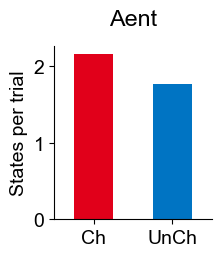

In [8]:
plt.figure(figsize = (2.6, 2.8))
plt.bar(['Ch', 'UnCh'], [np.array(num_states_chosen).mean(), np.array(num_states_unchosen).mean()], color = ['#e1001a', '#0074c3'], width = 0.5)
plt.xlim(-0.5, 1.5)
plt.ylabel('States per trial')
plt.title('Aent', pad = 15)
plt.tight_layout()
plt.show()

## Sequences

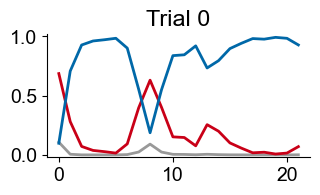

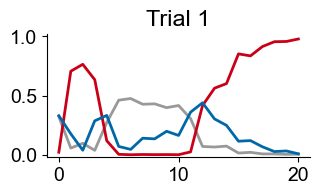

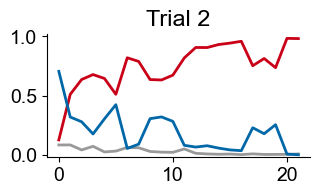

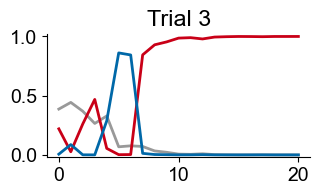

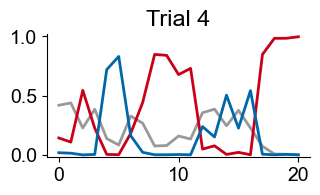

In [9]:
for i in  range(5):
    length_ep, values_ep, fixation_seq_ep, decision_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'decisions', 'hidden_seqs'
    )

    if values_ep[0] != values_ep[1]:

        # get values
        value_chosen = int(values_ep[decision_ep])
        value_unchosen = int(values_ep[1 - decision_ep])
        values_unavailable = np.arange(1, 5)[(np.arange(1, 5) != value_chosen) & (np.arange(1, 5) != value_unchosen)]

        # transform into posterior
        posteriors_ep = lda.predict_proba(np.array(hidden_seq_ep)[1:])

        # get posterior sequences
        post_chosen = posteriors_ep[:, value_chosen - 1]
        post_unchosen = posteriors_ep[:, value_unchosen - 1]
        post_unavailable = posteriors_ep[:, values_unavailable - 1].mean(axis = 1)

        proba  = lda.predict_proba(np.array(hidden_seq_ep[1:]))

        plt.figure(figsize = (3.4, 1.6))
        plt.plot(post_chosen, color = '#C90017', linewidth = 2)
        plt.plot(post_unchosen, color = '#0068A8', linewidth = 2)
        plt.plot(post_unavailable, color = '#999999', linewidth = 2, zorder = 0)
        plt.ylim(-0.02, 1.02)
        plt.yticks([0, 0.5, 1])
        plt.title(f'Trial {i}')
        plt.show()

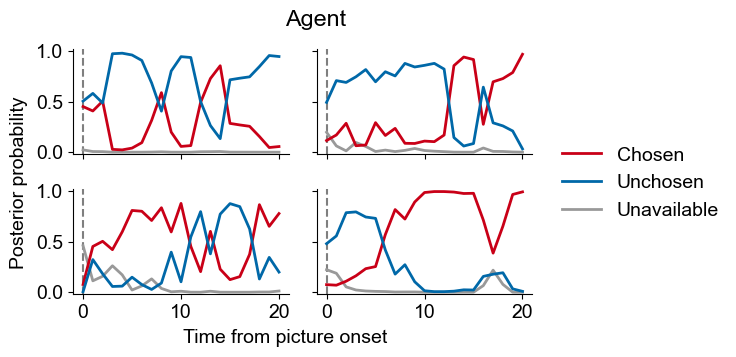

In [10]:
trials = [2361, 324, 1513, 5581]

fig, axes = plt.subplots(2, 2, figsize = (5.4, 3.2), sharex = True, sharey = True)
axes = axes.flatten()

for ax, i in zip(axes, trials):

    length_ep, values_ep, fixation_seq_ep, decision_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'decisions', 'hidden_seqs'
    )

    # get values
    value_chosen = int(values_ep[decision_ep])
    value_unchosen = int(values_ep[1 - decision_ep])
    values_unavailable = np.arange(1, 5)[(np.arange(1, 5) != value_chosen) & (np.arange(1, 5) != value_unchosen)]

    # transform into posterior
    posteriors_ep = lda.predict_proba(np.array(hidden_seq_ep)[1:])

    # get posterior sequences
    post_chosen = posteriors_ep[:, value_chosen - 1]
    post_unchosen = posteriors_ep[:, value_unchosen - 1]
    post_unavailable = posteriors_ep[:, values_unavailable - 1].mean(axis = 1)

    # plot
    ax.plot(post_chosen, color = '#C90017', linewidth = 2, label = 'Chosen')
    ax.plot(post_unchosen, color = '#0068A8', linewidth = 2, label = 'Unchosen')
    ax.plot( post_unavailable, color = '#999999', linewidth = 2, zorder = 0, label = 'Unavailable')
    ax.axvline(x = 0, color = 'k', linestyle = '--', alpha = 0.5, zorder = -1)
    # ax.set_title(f'Trial {i}')
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks([0, 0.5, 1])

# Common x and y labels
fig.text(0.5, 0, 'Time from picture onset', ha = 'center', fontsize = 14)
fig.text(-0.01, 0.5, 'Posterior probability', va = 'center', rotation = 'vertical', fontsize = 14)
fig.text(0.5, 1.01, 'Agent', va = 'center', fontsize = 16.8)

# One legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc = 'center left', bbox_to_anchor = (0.98, 0.5), frameon = False)

plt.tight_layout()
# plt.show()
plt.savefig('figures/p_posterior_agent.pdf', bbox_inches = 'tight')